In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


In [2]:
file_2023 = "DATA TABLE-2023- SALE 50.xlsx"
file_2024 = "DATA TABLE-2024- SALE  51.xlsx"
file_2025 = "DATA TABLE-2025- SALE  46- up to November.xlsx"  # new file

df_2023 = pd.read_excel(file_2023, sheet_name="DATA")
df_2024 = pd.read_excel(file_2024, sheet_name="DATA")
df_2025 = pd.read_excel(file_2025, sheet_name="DATA")

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)


In [3]:
print("df_2023 shape:", df_2023.shape)
print("df_2024 shape:", df_2024.shape)
print("Combined shape:", df_all.shape)

df_2023.head(5)

df_2023 shape: (491606, 26)
df_2024 shape: (523263, 33)
Combined shape: (1503888, 33)


,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,BUYER CODE,BUYER NAME,CHEST,CATEGORY,MF/BF,MFREF,FACTORY,ELE1,ELE2,GROUP
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,S080,SUNSHINE CONSUMER LANKA,10.0,EX-ESTATE,MF,MF0062,KELANEIYA,High,WH,0
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,D332,DILMA CEYLON TEA CO PLC,10.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,U102,UNI WORLD TEAS (PVT) LT,20.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0


In [4]:
df_high = df_all[df_all["ELE1"] == "High"].copy()
print("high elevation rows:", len(df_high))
df_high[['YEAR', 'SALE NO', 'GRADE', 'QTY', 'PRICE', 'ELE1']].head()

high elevation rows: 235107


,YEAR,SALE NO,GRADE,QTY,PRICE,ELE1
2,2023,1,BOPF,580.0,1500.0,High
3,2023,1,PEK,480.0,1350.0,High
4,2023,1,BOPF,1160.0,1600.0,High
5,2023,1,BOPF,1160.0,1550.0,High
6,2023,1,BOPF,1160.0,1500.0,High


In [5]:
def make_weekly_high(df_high: pd.DataFrame) -> pd.DataFrame:
    df_tmp = df_high.copy()
    df_tmp["PRICE"] = pd.to_numeric(df_tmp["PRICE"], errors="coerce")
    df_tmp["QTY"]   = pd.to_numeric(df_tmp["QTY"], errors="coerce")

    df_tmp["value"] = df_tmp["PRICE"] * df_tmp["QTY"]

    grouped = (
        df_tmp
        .groupby(["YEAR", "SALE NO", "GRADE"], as_index=False)
        .agg(
            total_qty   = ("QTY", "sum"),
            total_value = ("value", "sum"),
        )
    )

    grouped["avg_price"] = grouped["total_value"] / grouped["total_qty"]

    grouped["week_date"] = (
        pd.to_datetime(grouped["YEAR"].astype(str), format="%Y")
        + pd.to_timedelta((grouped["SALE NO"] - 1) * 7, unit="D")
    )

    return grouped[["YEAR", "SALE NO", "GRADE", "total_qty", "avg_price", "week_date"]]

weekly_high = make_weekly_high(df_high)

print("Weekly high-elevation table head:")
display(weekly_high.head())

print("\nDistinct grades in high elevation:", weekly_high["GRADE"].nunique())
print("Sample grades:", sorted(weekly_high["GRADE"].unique())[:20])


Weekly high-elevation table head:


,YEAR,SALE NO,GRADE,total_qty,avg_price,week_date
0,2023,1,BM,20055.0,786.638743,2023-01-01
1,2023,1,BOP,103585.0,1504.226481,2023-01-01
2,2023,1,BOP1,4310.0,1669.095128,2023-01-01
3,2023,1,BOP1A,9420.0,833.439490,2023-01-01
4,2023,1,BOPA,13670.0,1021.536211,2023-01-01



Distinct grades in high elevation: 279
Sample grades: ['ABBFOSP', 'ABBOTSFORD', 'BABY TEA', 'BG01', 'BLOOMING', 'BM', 'BOP', 'BOP1', 'BOP1A', 'BOPA', 'BOPF', 'BOPFSP', 'BOPSP', 'BP', 'BP1', 'BPS', 'BT', 'BUD TEA', 'CAL TEA', 'CAMELL TIP']


In [6]:
import numpy as np
import pandas as pd

def compute_metrics(y_test, y_pred):
    """
    Robust metrics that:
      - align y_test and y_pred
      - ignore any NaNs
    """
    y_test = pd.Series(y_test).astype(float)
    y_pred = pd.Series(y_pred, index=y_test.index).astype(float)

    # difference
    diff = y_test - y_pred

    # Ignore NaNs in metrics
    mae  = np.nanmean(np.abs(diff))
    rmse = np.sqrt(np.nanmean(diff ** 2))

    y_safe = y_test.clip(lower=1e-3)
    mape = np.nanmean(np.abs(diff / y_safe)) * 100

    return float(mae), float(rmse), float(mape)


In [7]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def train_arima_for_grade_high(
    weekly_high: pd.DataFrame,
    grade: str,
    min_points: int = 30,
    test_weeks: int = 52,
):
    gdf = weekly_high[weekly_high["GRADE"] == grade].copy()
    gdf = gdf.sort_values("week_date")
    gdf = gdf.dropna(subset=["avg_price"])

    if len(gdf) < min_points:
        print(f"⚠️ Grade {grade}: only {len(gdf)} valid points after dropping NaNs, skipping.")
        return None

    y = pd.Series(gdf["avg_price"].values, index=gdf["week_date"]).astype(float)

    if len(y) <= test_weeks + 10:
        split_idx = int(len(y) * 0.8)
    else:
        split_idx = len(y) - test_weeks

    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    if len(y_test) == 0:
        print(f"⚠️ Grade {grade}: empty test set, skipping.")
        return None

    model_train = ARIMA(y_train, order=(1, 1, 1))
    res_train   = model_train.fit()

    y_pred_raw = res_train.forecast(steps=len(y_test))
    y_pred     = pd.Series(np.asarray(y_pred_raw, dtype=float), index=y_test.index)

    diff = y_test - y_pred

    mae  = float(np.nanmean(np.abs(diff)))
    rmse = float(np.sqrt(np.nanmean(diff**2)))
    mape = float(np.nanmean(np.abs(diff / y_test.clip(lower=1e-3))) * 100)

    model_full = ARIMA(y, order=(1, 1, 1)).fit()

    return {
        "grade": grade,
        "n_points": len(y),
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "model": model_full,           
        "y_price": y,                  
        "y_test_price": y_test,        
        "y_pred_test_price": y_pred,   
    }


In [8]:
results_high_arima = []
models_high_arima  = {}

for g in sorted(weekly_high["GRADE"].unique()):
    print(f"→ Grade {g}")
    info = train_arima_for_grade_high(weekly_high, g)

    if info is None:
        continue

    results_high_arima.append({
        "elevation": "High",
        "grade": info["grade"],
        "n_points": info["n_points"],
        "MAE": info["mae"],
        "RMSE": info["rmse"],
        "MAPE_%": info["mape"],
    })
    models_high_arima[g] = info

metrics_high_arima = pd.DataFrame(results_high_arima).sort_values("MAPE_%")
display(metrics_high_arima.head(20))


→ Grade ABBFOSP
⚠️ Grade ABBFOSP: only 14 valid points after dropping NaNs, skipping.
→ Grade ABBOTSFORD
⚠️ Grade ABBOTSFORD: only 7 valid points after dropping NaNs, skipping.
→ Grade BABY TEA
⚠️ Grade BABY TEA: only 1 valid points after dropping NaNs, skipping.
→ Grade BG01
⚠️ Grade BG01: only 6 valid points after dropping NaNs, skipping.
→ Grade BLOOMING
⚠️ Grade BLOOMING: only 24 valid points after dropping NaNs, skipping.
→ Grade BM
→ Grade BOP


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

→ Grade BOP1
→ Grade BOP1A
→ Grade BOPA
→ Grade BOPF


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

→ Grade BOPFSP
→ Grade BOPSP
→ Grade BP


...

→ Grade SCALPAGOLD
⚠️ Grade SCALPAGOLD: only 4 valid points after dropping NaNs, skipping.
→ Grade SENCHA OP
⚠️ Grade SENCHA OP: only 1 valid points after dropping NaNs, skipping.
→ Grade SIL SPIRAL
⚠️ Grade SIL SPIRAL: only 1 valid points after dropping NaNs, skipping.
→ Grade SILVER GRE
⚠️ Grade SILVER GRE: only 1 valid points after dropping NaNs, skipping.
→ Grade SILVER RIN
⚠️ Grade SILVER RIN: only 1 valid points after dropping NaNs, skipping.
→ Grade SILVER TIP
→ Grade SILVERTIPS
→ Grade SIVER CURL
⚠️ Grade SIVER CURL: only 10 valid points after dropping NaNs, skipping.
→ Grade SPEC.TEA
⚠️ Grade SPEC.TEA: only 1 valid points after dropping NaNs, skipping.
→ Grade SPECIAL TE
⚠️ Grade SPECIAL TE: only 17 valid points after dropping NaNs, skipping.
→ Grade SPECIALITE
⚠️ Grade SPECIALITE: only 1 valid points after dropping NaNs, skipping.
→ Grade SUNNYBLOOM
⚠️ Grade SUNNYBLOOM: only 1 valid points after dropping NaNs, skipping.
→ Grade TEA COINS
⚠️ Grade TEA COINS: only 8 valid point

C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

→ Grade WHITE TIP
⚠️ Grade WHITE TIP: only 9 valid points after dropping NaNs, skipping.
→ Grade WHITE TIPS
⚠️ Grade WHITE TIPS: only 3 valid points after dropping NaNs, skipping.
→ Grade WHITETEA
⚠️ Grade WHITETEA: only 1 valid points after dropping NaNs, skipping.
→ Grade WINTERPEK
⚠️ Grade WINTERPEK: only 4 valid points after dropping NaNs, skipping.
→ Grade YENSA TEA
⚠️ Grade YENSA TEA: only 2 valid points after dropping NaNs, skipping.
→ Grade YH
→ Grade YH2
→ Grade YHS
⚠️ Grade YHS: only 11 valid points after dropping NaNs, skipping.
→ Grade YOXFORD TW
⚠️ Grade YOXFORD TW: only 1 valid points after dropping NaNs, skipping.


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

,elevation,grade,n_points,MAE,RMSE,MAPE_%
13,High,D2,71,0.000000,0.000000,0.000000
30,High,GOLDENTIPS,35,504.252169,892.654410,1.610049
48,High,GTS,40,20.644156,22.264348,2.576079
52,High,GTYHSP,55,40.622383,58.212839,2.652928
32,High,GPOPA2,39,35.020851,36.726429,2.806988
47,High,GTOPA2,98,38.739556,59.674651,2.961683
35,High,GPYH,42,42.915401,65.159057,3.012243
50,High,GTYH,130,43.590147,62.792011,3.092231
17,High,FBOP,147,52.456560,66.218196,4.074464
61,High,PF1,147,48.702817,56.637644,4.463112


In [9]:
metrics_high_arima.to_csv("high_elevation_arima_metrics.csv", index=False)


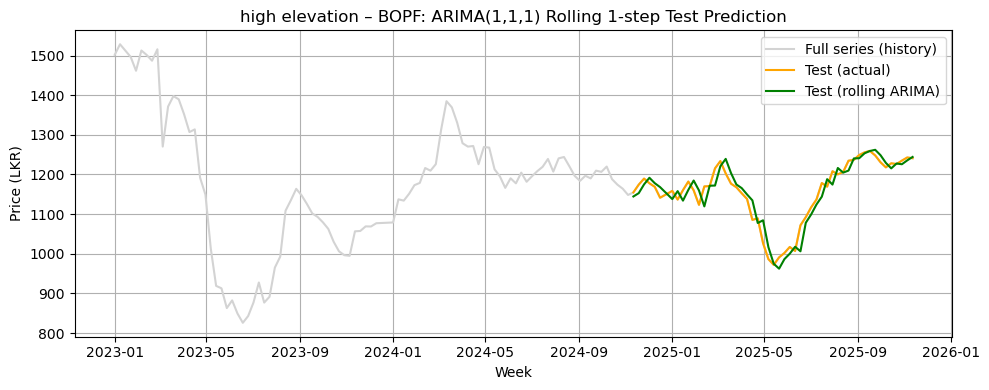

Rolling 1-step: MAE=19.30, RMSE=24.25, MAPE=1.70%


In [10]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def rolling_arima_forecast(y, order=(1,1,1), test_weeks=52):
    """
    y: pd.Series with DateTimeIndex
    Returns:
      y_train, y_test, y_pred_rolling
    """
    if len(y) <= test_weeks + 10:
        split_idx = int(len(y) * 0.8)
    else:
        split_idx = len(y) - test_weeks

    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    history = list(y_train.values)
    preds   = []

    for t in range(len(y_test)):
        model = ARIMA(history, order=order)
        res   = model.fit()
        preds.append(res.forecast(steps=1)[0])
        # update with the TRUE value
        history.append(y_test.iloc[t])

    y_pred_roll = pd.Series(preds, index=y_test.index)
    return y_train, y_test, y_pred_roll

gdf_high = weekly_high[weekly_high["GRADE"] == "BOPF"].copy()
gdf_mid = gdf_high.sort_values("week_date").dropna(subset=["avg_price"])

y_high = pd.Series(gdf_high["avg_price"].values,
                  index=gdf_high["week_date"]).astype(float)

y_train, y_test, y_pred_roll = rolling_arima_forecast(
    y_high, order=(1,1,1), test_weeks=52
)

plt.figure(figsize=(10,4))
plt.plot(y_high.index, y_high.values, color="lightgray",
         label="Full series (history)")
plt.plot(y_test.index, y_test.values, label="Test (actual)", color="orange")
plt.plot(y_pred_roll.index, y_pred_roll.values,
         label="Test (rolling ARIMA)", color="green")
plt.title("high elevation – BOPF: ARIMA(1,1,1) Rolling 1-step Test Prediction")
plt.ylabel("Price (LKR)")
plt.xlabel("Week")
plt.legend()
plt.tight_layout()
plt.show()

diff = y_test - y_pred_roll
mae  = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))
mape = np.mean(np.abs(diff / y_test.clip(lower=1e-3))) * 100
print(f"Rolling 1-step: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")



In [11]:
def print_metrics_for_high_arima_grade(grade="BOPF"):
    info = models_high_arima[grade]
    mae  = info["mae"]
    rmse = info["rmse"]
    mape = info["mape"]

    print(f"ARIMA – high elevation – {grade}")
    print(f"  MAE  : {mae:.6f} LKR")
    print(f"  RMSE : {rmse:.6f} LKR")
    print(f"  MAPE : {mape:.6f} %")


print_metrics_for_high_arima_grade("BOPF")

ARIMA – high elevation – BOPF
  MAE  : 69.537035 LKR
  RMSE : 81.787698 LKR
  MAPE : 6.064732 %


In [12]:
metrics_high_arima_all = metrics_high_arima.sort_values("MAPE_%")
display(metrics_high_arima_all.head(20))


,elevation,grade,n_points,MAE,RMSE,MAPE_%
13,High,D2,71,0.000000,0.000000,0.000000
30,High,GOLDENTIPS,35,504.252169,892.654410,1.610049
48,High,GTS,40,20.644156,22.264348,2.576079
52,High,GTYHSP,55,40.622383,58.212839,2.652928
32,High,GPOPA2,39,35.020851,36.726429,2.806988
47,High,GTOPA2,98,38.739556,59.674651,2.961683
35,High,GPYH,42,42.915401,65.159057,3.012243
50,High,GTYH,130,43.590147,62.792011,3.092231
17,High,FBOP,147,52.456560,66.218196,4.074464
61,High,PF1,147,48.702817,56.637644,4.463112


In [13]:
future_rows_arima = []

N_FUTURE_WEEKS = 52  

for g, info in models_high_arima.items():
    model = info["model"]         
    y_price_full = info["y_price"]

    last_date = y_price_full.index[-1]

    future_index = pd.date_range(
        start=last_date + pd.Timedelta(days=7),
        periods=N_FUTURE_WEEKS,
        freq="7D"
    )

    future_vals = model.forecast(steps=N_FUTURE_WEEKS)
    future_series = pd.Series(np.asarray(future_vals, float), index=future_index)

    tmp = pd.DataFrame({
        "elevation": "High",
        "grade": g,
        "date": future_series.index,
        "predicted_price": future_series.values,
    })
    future_rows_arima.append(tmp)

future_high_arima_df = pd.concat(future_rows_arima, ignore_index=True)


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_pre

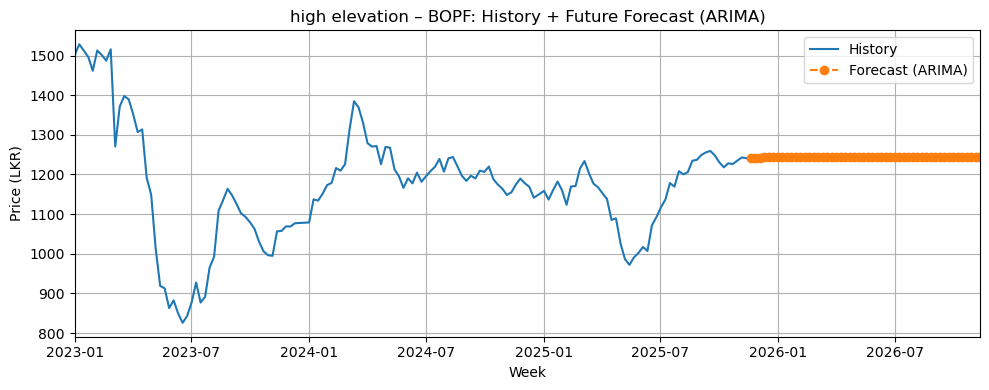

In [14]:
grade_for_demo = "BOPF"

hist_high = models_high_arima[grade_for_demo]["y_price"]
future_grade = future_high_arima_df[future_high_arima_df["grade"] == grade_for_demo]

plt.figure(figsize=(10, 4))
plt.plot(hist_high.index, hist_high.values, label="History")

plt.plot(
    future_grade["date"],
    future_grade["predicted_price"],
    marker="o",
    linestyle="--",
    label="Forecast (ARIMA)",
)

# make sure x-axis covers both history + future
plt.xlim(hist_high.index.min(), future_grade["date"].max())

plt.title(f"high elevation – {grade_for_demo}: History + Future Forecast (ARIMA)")
plt.ylabel("Price (LKR)")
plt.xlabel("Week")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
grade = "BOPF"
info = models_high_arima[grade]

y_test = info["y_test_price"]
y_pred = info["y_pred_test_price"]

print("len(y_test):", len(y_test))
print("len(y_pred):", len(y_pred))

cmp = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
print(cmp.head(10))

print("\nDifferences:")
print((cmp["y_test"] - cmp["y_pred"]).abs().describe())


len(y_test): 52
len(y_pred): 52
                 y_test       y_pred
week_date                           
2024-11-11  1154.847811  1144.566631
2024-11-18  1174.399056  1141.544122
2024-11-25  1189.643592  1139.133291
2024-12-02  1177.870396  1137.210351
2024-12-09  1168.879775  1135.676565
2024-12-16  1141.352106  1134.453177
2025-01-01  1158.611471  1133.477373
2025-01-08  1136.677059  1132.699046
2025-01-15  1160.548426  1132.078232
2025-01-22  1182.166449  1131.583056

Differences:
count     52.000000
mean      69.537035
std       43.476176
min        3.978013
25%       36.150617
50%       64.235282
75%      105.844232
max      157.585849
dtype: float64


In [27]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

def diagnose_arima_in_sample(models_dict, grade: str, elevation_label: str = "High"):
    """
    In-sample residual diagnostics for ARIMA model of a given grade.
    Uses the full-series model stored in models_*_arima[grade]["model"].
    """
    if grade not in models_dict:
        raise KeyError(f"Grade {grade} not found. Available: {list(models_dict.keys())}")

    info = models_dict[grade]
    model_full = info["model"]      
    resid = pd.Series(model_full.resid)

    print(f"=== In-sample residual diagnostics – {elevation_label} – {grade} – ARIMA ===\n")

    print("Residual summary:")
    print(resid.describe())
    print("\nMean residual (should be close to 0):", resid.mean())

    resid_clean = resid.dropna()
    lb = sm.stats.acorr_ljungbox(resid_clean, lags=[10, 20, 30], return_df=True)
    print("\nLjung–Box test for residual autocorrelation:")
    print(lb)

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))

    axes[0, 0].plot(resid.index, resid.values)
    axes[0, 0].axhline(0, color='black', linewidth=1)
    axes[0, 0].set_title("Residuals over time")
    axes[0, 0].set_xlabel("Week")
    axes[0, 0].set_ylabel("Residual")

    
    axes[0, 1].hist(resid.values, bins=20)
    axes[0, 1].set_title("Residual histogram")

    sm.graphics.tsa.plot_acf(resid_clean, ax=axes[1, 0], lags=30)
    axes[1, 0].set_title("ACF of residuals")

    sm.qqplot(resid_clean, line='s', ax=axes[1, 1])
    axes[1, 1].set_title("QQ-plot of residuals")

    plt.tight_layout()
    plt.show()

    return lb, resid


In [28]:
def full_arima_diagnostics_for_grade(models_dict, grade: str, elevation_label: str = "High"):
    print("\n" + "="*80)
    print(f"ARIMA diagnostics for {elevation_label} – {grade}")
    print("="*80 + "\n")

    lb_df, resid_full = diagnose_arima_in_sample(models_dict, grade, elevation_label)
    resid_test = diagnose_arima_test_residuals(models_dict, grade, elevation_label)

    return lb_df, resid_full, resid_test



ARIMA diagnostics for High – BOPF

=== In-sample residual diagnostics – High – BOPF – ARIMA ===

Residual summary:
count     147.000000
mean        9.054847
std       130.110108
min      -247.621475
25%       -18.478578
50%        -1.944565
75%        17.089879
max      1501.526476
dtype: float64

Mean residual (should be close to 0): 9.054847396287528

Ljung–Box test for residual autocorrelation:
     lb_stat  lb_pvalue
10  5.057742   0.887288
20  7.875208   0.992662
30  9.190090   0.999908


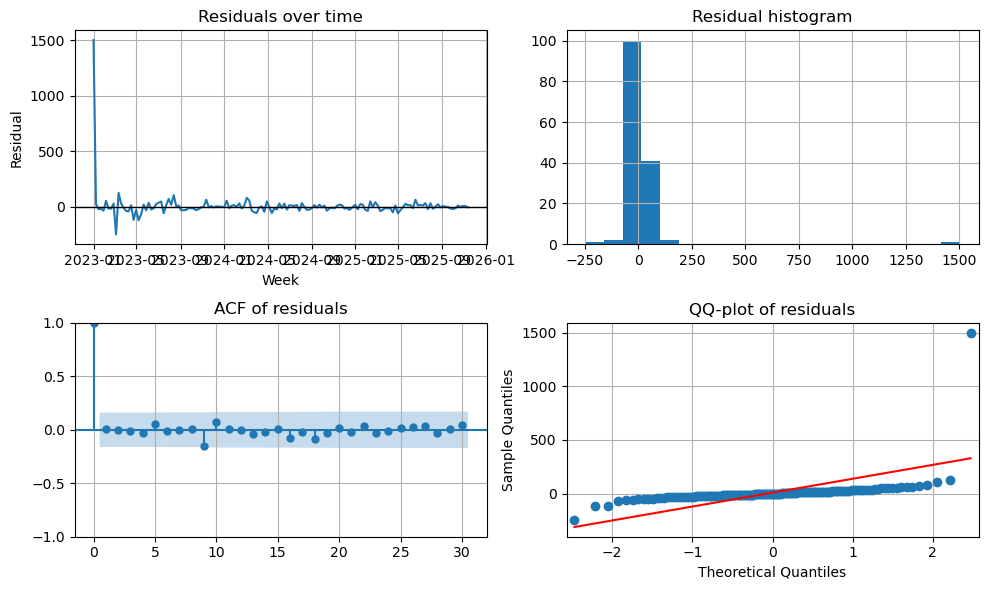

=== Test residual diagnostics – High – BOPF – ARIMA ===

Test residual summary:
count     52.000000
mean      27.048578
std       77.938551
min     -157.585849
25%        1.131662
50%       39.466321
75%       90.435379
max      129.781239
dtype: float64

Mean test residual: 27.048578421492206
Std of test residual: 77.93855085313841


In [29]:
lb_high_bopf, resid_high_bopf, test_resid_high_bopf = full_arima_diagnostics_for_grade(
    models_high_arima,
    grade="BOPF",
    elevation_label="High"
)



In [30]:
import matplotlib.pyplot as plt

def plot_train_test_split(weekly_df, elevation_label: str, grade: str = "BOPF", n_test: int = 52):
    """
    Plot actual weekly price with Train vs Test split.

    weekly_df      : DataFrame with columns ["ELEVATION", "GRADE", "week_date", "avg_price"]
    elevation_label: just for title ("Low", "Medium", "High")
    grade          : tea grade, e.g. "BOPF"
    n_test         : number of last weeks used as TEST (e.g. 52)
    """

    gdf = weekly_df[weekly_df["GRADE"] == grade].copy()
    gdf = gdf.sort_values("week_date")

    if gdf.empty:
        print(f"No data found for {elevation_label} – {grade}")
        return

    y = gdf.set_index("week_date")["avg_price"].astype(float)

    if len(y) <= n_test:
        print(f"Not enough points for {elevation_label} – {grade}. Length={len(y)}, n_test={n_test}")
        return

    split_idx = len(y) - n_test
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    print(f"=== {elevation_label} – {grade} ===")
    print(f"Total points: {len(y)}")
    print(f"Train points: {len(y_train)}  ({y_train.index[0].date()} → {y_train.index[-1].date()})")
    print(f"Test points : {len(y_test)}   ({y_test.index[0].date()} → {y_test.index[-1].date()})")

    plt.figure(figsize=(10, 4))
    plt.plot(y.index, y.values, color="lightgray", label="Full series (actual)")

    plt.plot(y_train.index, y_train.values, label="Train (actual)", color="blue")
    plt.plot(y_test.index,  y_test.values,  label="Test (actual)",  color="orange")

    split_date = y_test.index[0]
    plt.axvline(split_date, color="red", linestyle="--", label=f"Split ({split_date.date()})")

    plt.title(f"{elevation_label} – {grade}: Weekly price (Train vs Test)")
    plt.xlabel("Week")
    plt.ylabel("Average price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()


=== High – BOPF ===
Total points: 147
Train points: 95  (2023-01-01 → 2024-11-04)
Test points : 52   (2024-11-11 → 2025-11-12)


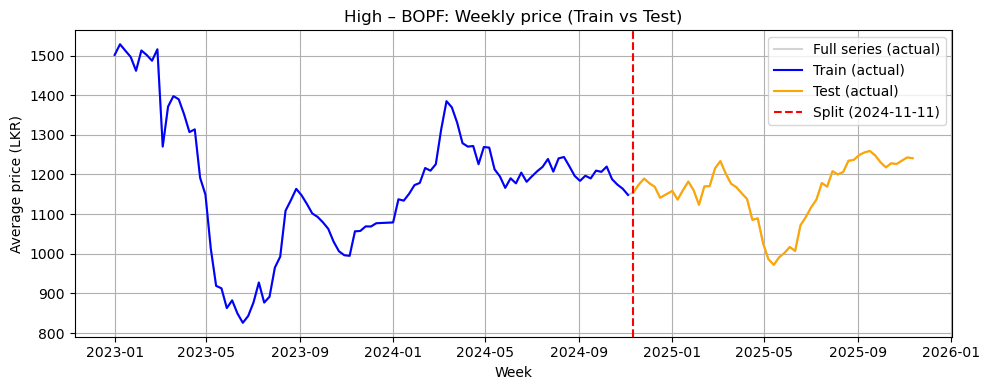

In [31]:
plot_train_test_split(weekly_high, "High", "BOPF", n_test=52)


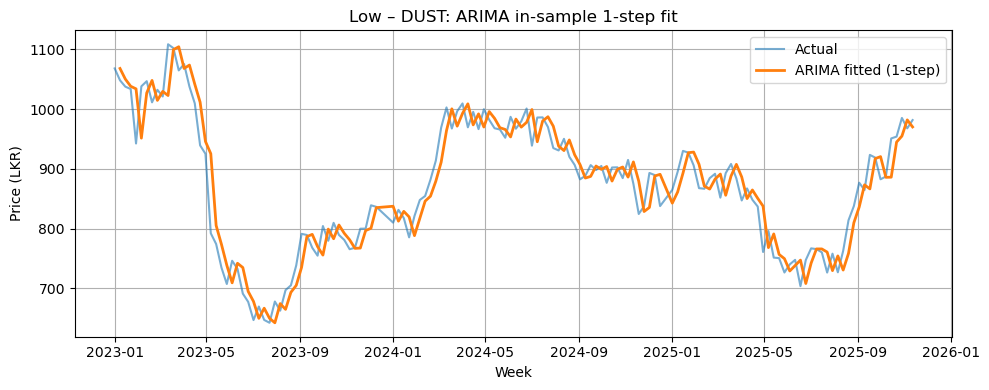

In [32]:
grade = "DUST"
info = models_high_arima[grade]

model_full = info["model"]
y = info["y_price"]   

fitted = model_full.predict(start=y.index[1], end=y.index[-1], dynamic=False)

plt.figure(figsize=(10,4))
plt.plot(y.index, y.values, label="Actual", alpha=0.6)
plt.plot(fitted.index, fitted.values, label="ARIMA fitted (1-step)", linewidth=2)
plt.title("Low – DUST: ARIMA in-sample 1-step fit")
plt.xlabel("Week")
plt.ylabel("Price (LKR)")
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
import pickle

with open("arima_high_grade_model.pkl", "wb") as f:
    pickle.dump(models_high_arima[grade_for_demo]["model"], f)

